In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


pd.set_option("display.max_rows", 10000)
pd.set_option('display.max_columns',15)
pd.set_option('display.width', 10000)

In [2]:
dataset = pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
dataset.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited'], dtype='object')

In [4]:
dataset.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


#  Exited      = Dependent variable
# Drop : RowNumber ,CustomerId,  Surname  

In [6]:
dataset = dataset.iloc[:,3:]
dataset.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Encoding 

In [8]:
dataset['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
dataset['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [10]:
dataset['Gender'] = dataset['Gender'].astype('category')
dataset['Gender'] = dataset['Gender'].cat.codes

In [11]:
dataset['Gender']

0       0
1       0
2       0
3       0
4       0
5       1
6       1
7       0
8       1
9       1
10      1
11      1
12      0
13      0
14      0
15      1
16      1
17      0
18      1
19      0
20      1
21      0
22      0
23      1
24      0
25      1
26      1
27      1
28      0
29      1
30      0
31      1
32      1
33      0
34      0
35      0
36      1
37      1
38      1
39      1
40      1
41      0
42      0
43      0
44      0
45      0
46      0
47      0
48      1
49      0
50      1
51      1
52      0
53      1
54      1
55      1
56      1
57      1
58      0
59      1
60      1
61      0
62      1
63      1
64      1
65      0
66      0
67      1
68      0
69      0
70      1
71      1
72      0
73      0
74      1
75      0
76      1
77      0
78      1
79      0
80      0
81      0
82      0
83      0
84      0
85      0
86      1
87      1
88      0
89      0
90      0
91      1
92      0
93      1
94      1
95      1
96      1
97      1
98      1
99      1


In [12]:
# dataset = pd.get_dummies(dataset, columns=['Geography'])
# dataset = dataset.drop(['Geography_France'], axis=1)
dataset = pd.get_dummies(dataset, columns=['Geography'], drop_first=True)

In [13]:
dataset.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int8   
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  bool   
 11  Geography_Spain    10000 non-null  bool   
dtypes: bool(2), float64(2), int64(7), int8(1)
memory usage: 732.5 KB


# To know about unique values and their count

In [15]:
for col in dataset.columns:
    print("********", col, "********")
    print("Unique Values:", dataset[col].unique())
    print()
    print("Count:", dataset[col].nunique())
    print()

******** CreditScore ********
Unique Values: [619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662 659 523 772 545 634 739 771
 681 544 696 766 727 693 557 531 498 651 791 733 811 707 714 782 775 799
 602 744 588 747 583 627 731 629 438 642 806 474 559 429 680 749 734 644
 626 649 805 718 840 630 654 762 568 613 522 737 648 443 640 540 460 593
 801 6

In [16]:
def boxplots(df, col):
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

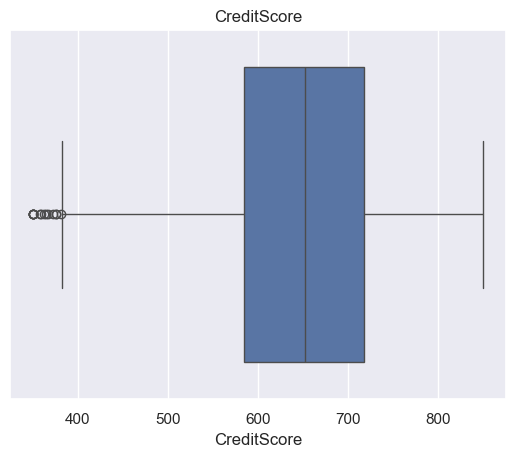

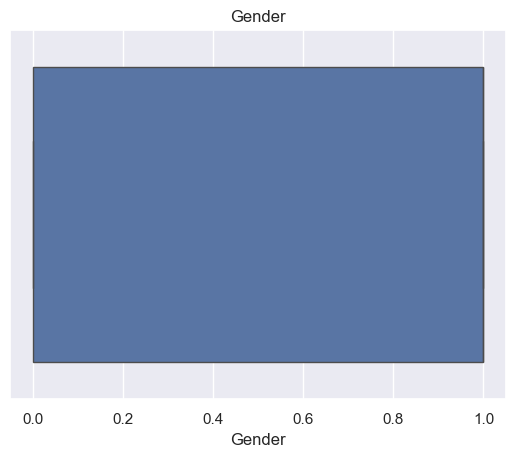

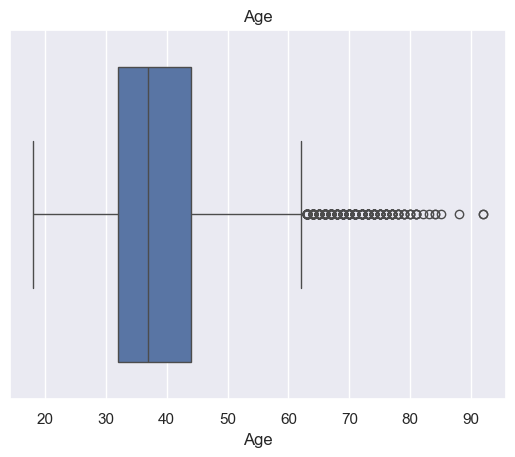

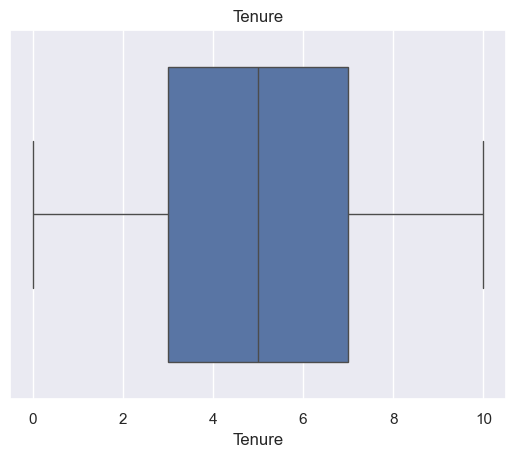

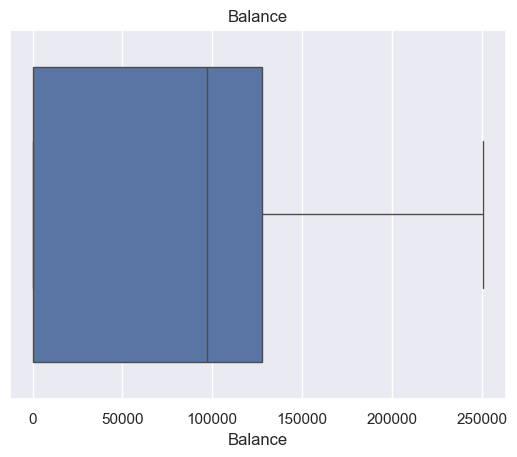

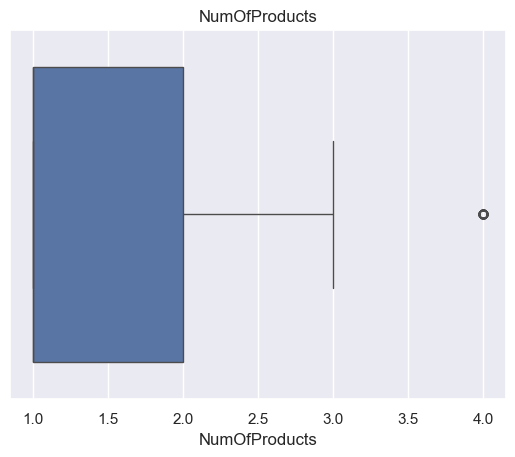

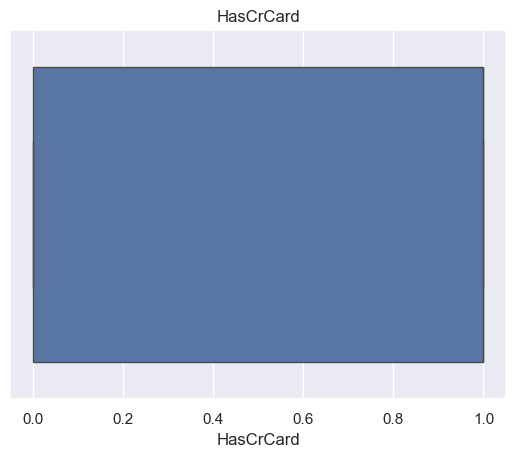

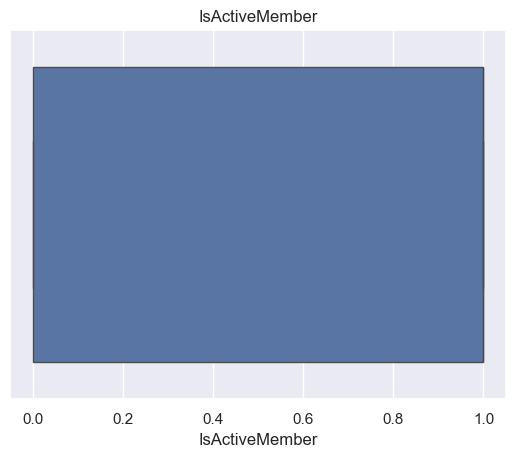

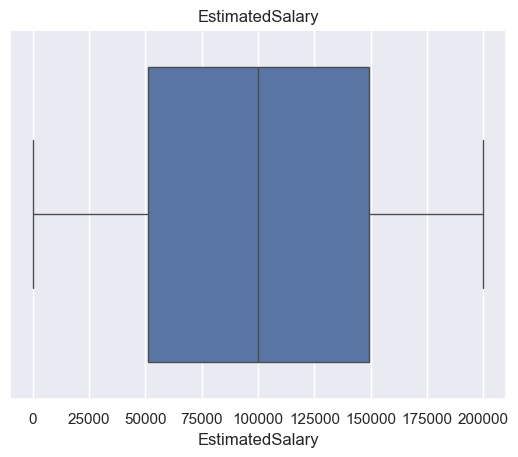

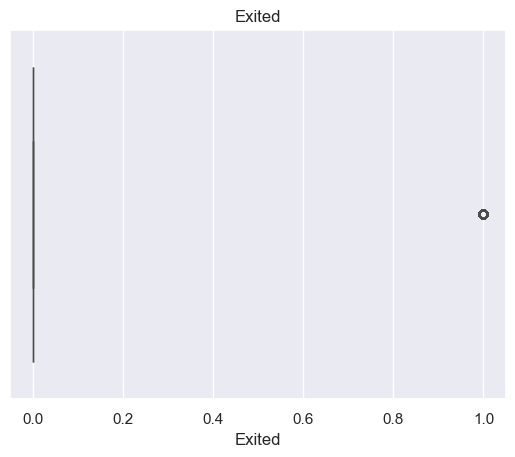

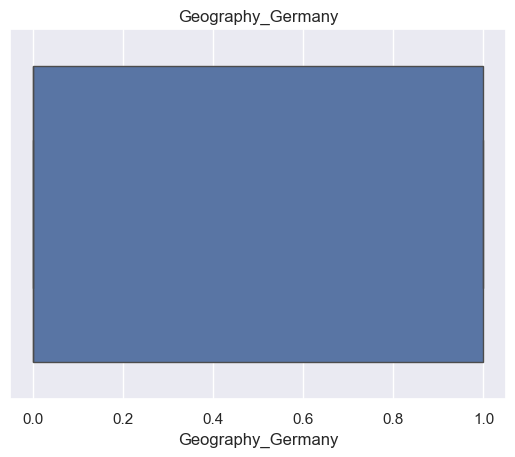

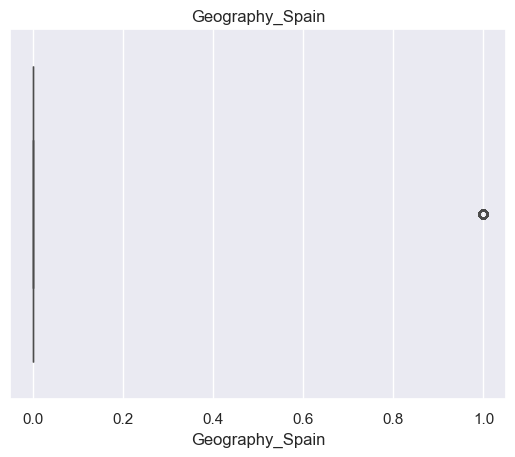

In [17]:
num_cols = dataset.select_dtypes(exclude=['object']).columns
for col in num_cols:
    boxplots(dataset, col)

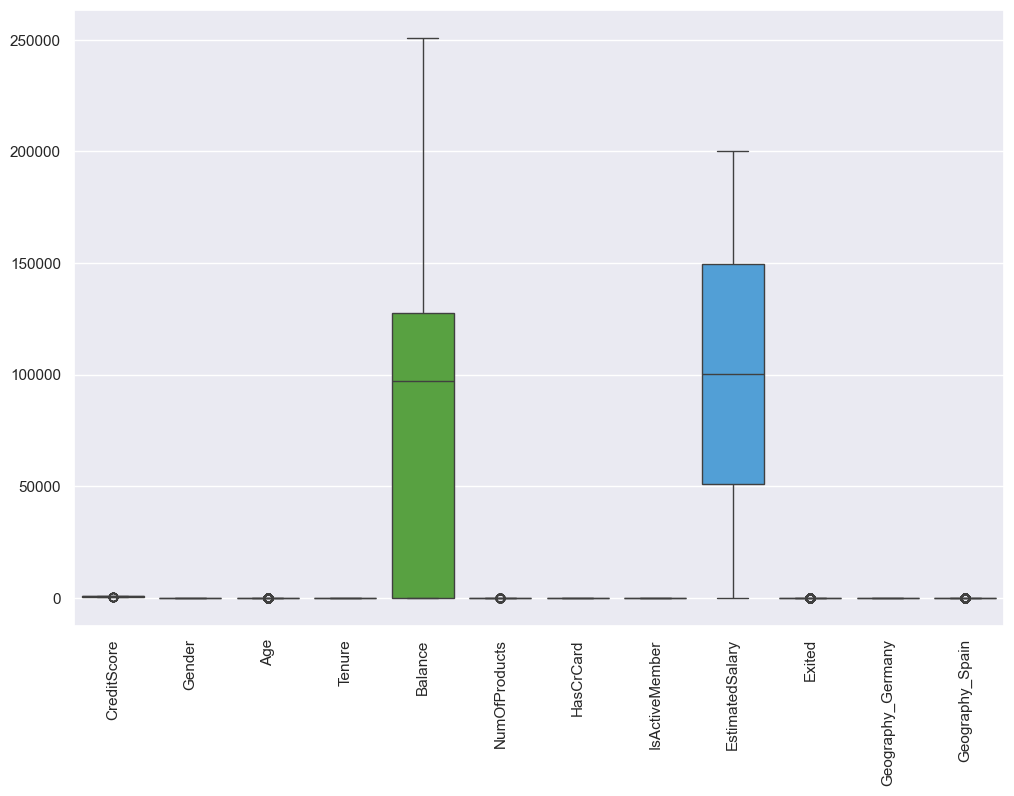

In [18]:
# Advanced Tip (Very Useful for Teaching): if you want to plot all boxplots in one figure:
plt.figure(figsize=(12,8))
sns.boxplot(data=dataset.select_dtypes(exclude='object'))
plt.xticks(rotation=90)
plt.show()

# Split the data into ind variable and dep variable

In [19]:
x = dataset.drop(['Exited'], axis=1)
y = dataset[['Exited']]

In [20]:
x.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


In [21]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


# Feature Scaling required

In [22]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x1 = sc.fit_transform(x)


In [23]:
pd.DataFrame(x1).head()

,0,1,2,3,4,5,6,7,8,9,10
0,-0.326221,-1.095988,0.293517,-1.041760,-1.225848,-0.911583,0.646092,0.970243,0.021886,-0.578736,-0.573809
1,-0.440036,-1.095988,0.198164,-1.387538,0.117350,-0.911583,-1.547768,0.970243,0.216534,-0.578736,1.742740
2,-1.536794,-1.095988,0.293517,1.032908,1.333053,2.527057,0.646092,-1.030670,0.240687,-0.578736,-0.573809
3,0.501521,-1.095988,0.007457,-1.387538,-1.225848,0.807737,-1.547768,-1.030670,-0.108918,-0.578736,-0.573809
4,2.063884,-1.095988,0.388871,-1.041760,0.785728,-0.911583,0.646092,0.970243,-0.365276,-0.578736,1.742740


# Check imbalance dataset

In [24]:
y.value_counts()

Exited
0         7963
1         2037
Name: count, dtype: int64

# As data is not balanced so we need to do data balancing

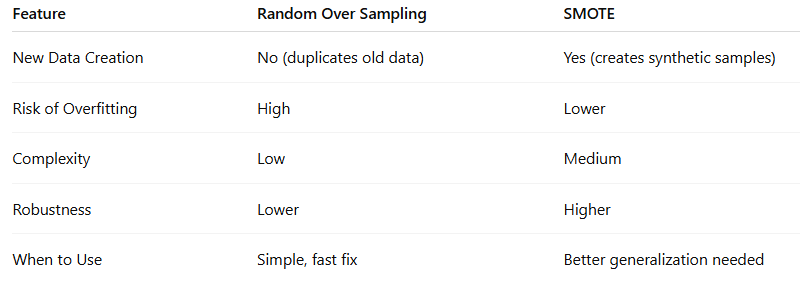

In [25]:
import imblearn
from imblearn.over_sampling import RandomOverSampler,SMOTE

In [26]:
ros = RandomOverSampler() 
x_sam, y_sam = ros.fit_resample(x1, y)


In [27]:
smo =  SMOTE()
x_sam_1, y_sam_1 = smo.fit_resample(x1, y)


In [28]:
print(x_sam.shape, y_sam.shape, y.shape)

(15926, 11) (15926, 1) (10000, 1)


In [ ]:
print(x_sam_1.shape, y_sam_1.shape, y.shape)

In [29]:
y_sam.value_counts()

Exited
0         7963
1         7963
Name: count, dtype: int64

In [30]:
y.value_counts()

Exited
0         7963
1         2037
Name: count, dtype: int64

In [31]:
dataset.corr()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
CreditScore,1.000000,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780
Gender,-0.002857,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512,-0.024628,0.016889
Age,-0.003965,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685
Tenure,0.000842,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868
Balance,0.006268,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892
NumOfProducts,0.012238,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039
HasCrCard,-0.005458,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480
IsActiveMember,0.025651,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732
EstimatedSalary,-0.001384,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482
Exited,-0.027094,-0.106512,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667


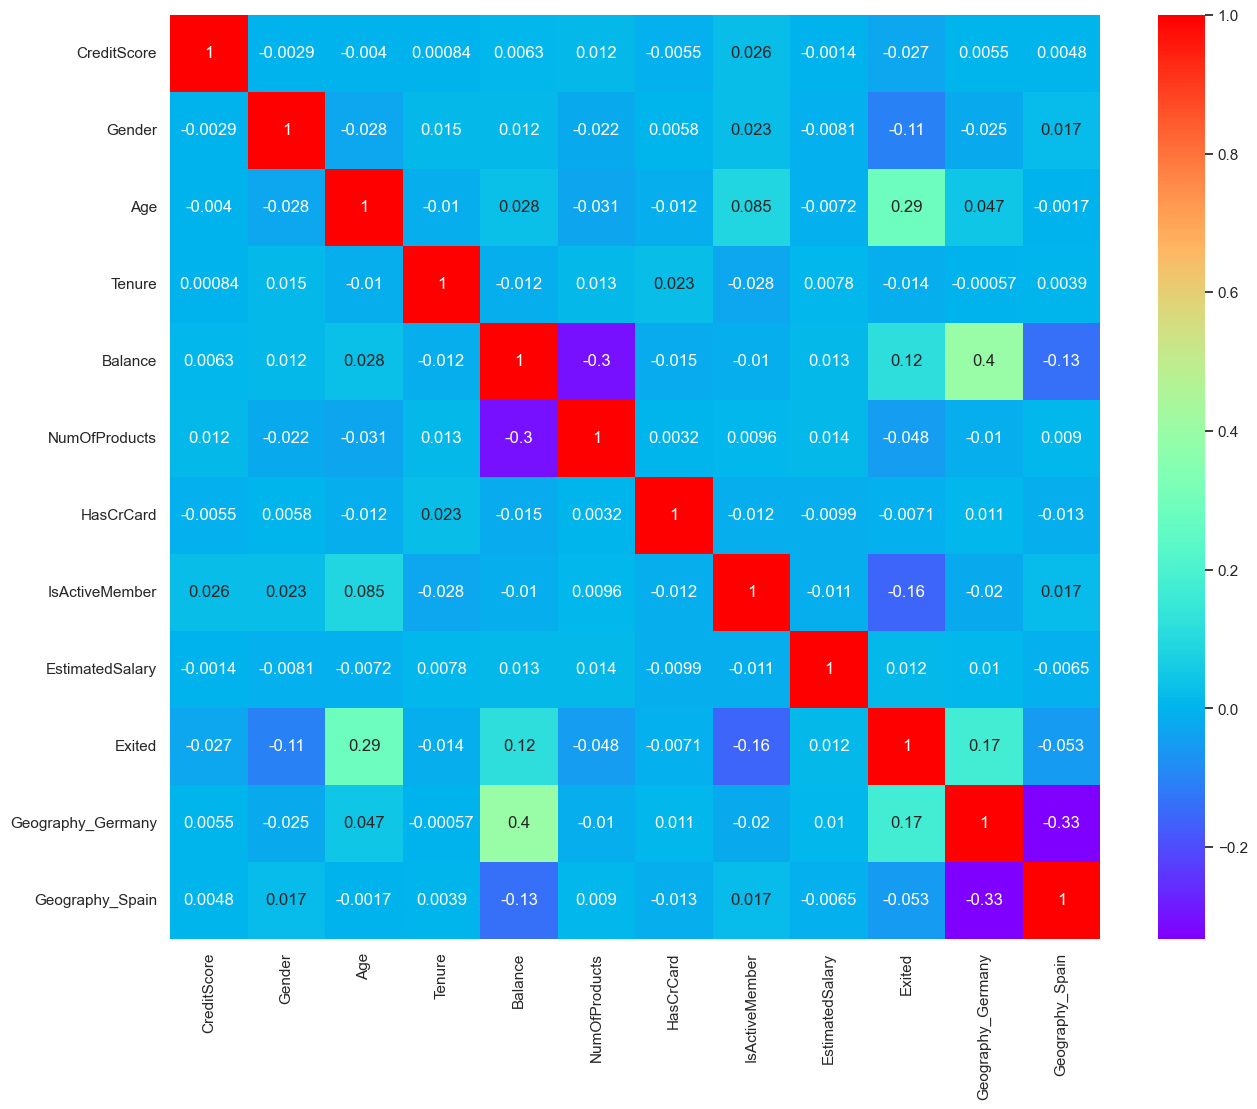

In [32]:
plt.figure(figsize=(15,12))
sns.heatmap(dataset.corr(), annot=True, cmap='rainbow')
plt.show()

In [ ]:
#sns.pairplot(dataset)

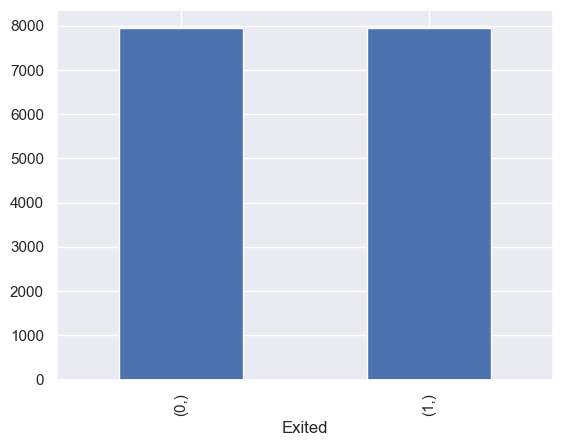

In [33]:
pd.DataFrame(y_sam).value_counts().plot(kind='bar')
plt.show()

<Axes: xlabel='Exited'>

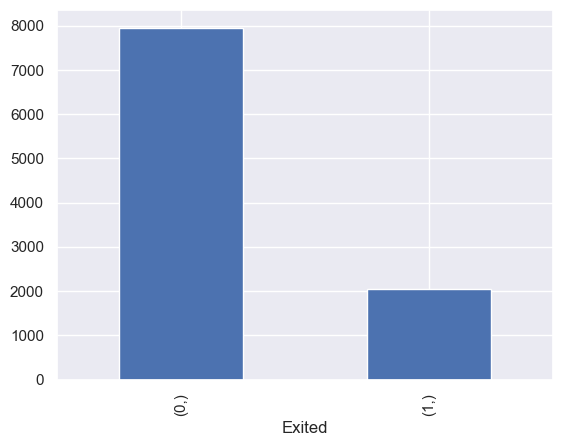

In [34]:
pd.DataFrame(y).value_counts().plot(kind='bar')

In [ ]:
dataset.info()

In [35]:
# Keep only non-boolean columns from x
x1 = [col for col in x if dataset[col].dtype != 'bool']
print(x1)

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [36]:
def histograms(dataset, variables, n_rows, n_cols):
    fig = plt.figure(figsize=(20,15))
    for i , var_name in enumerate(variables):
        ax = fig.add_subplot(n_rows, n_cols, i+1)
        dataset[var_name].hist(bins=10, ax=ax)
        ax.set_title(var_name +"Distribution")
    fig.tight_layout()
    plt.show()
    

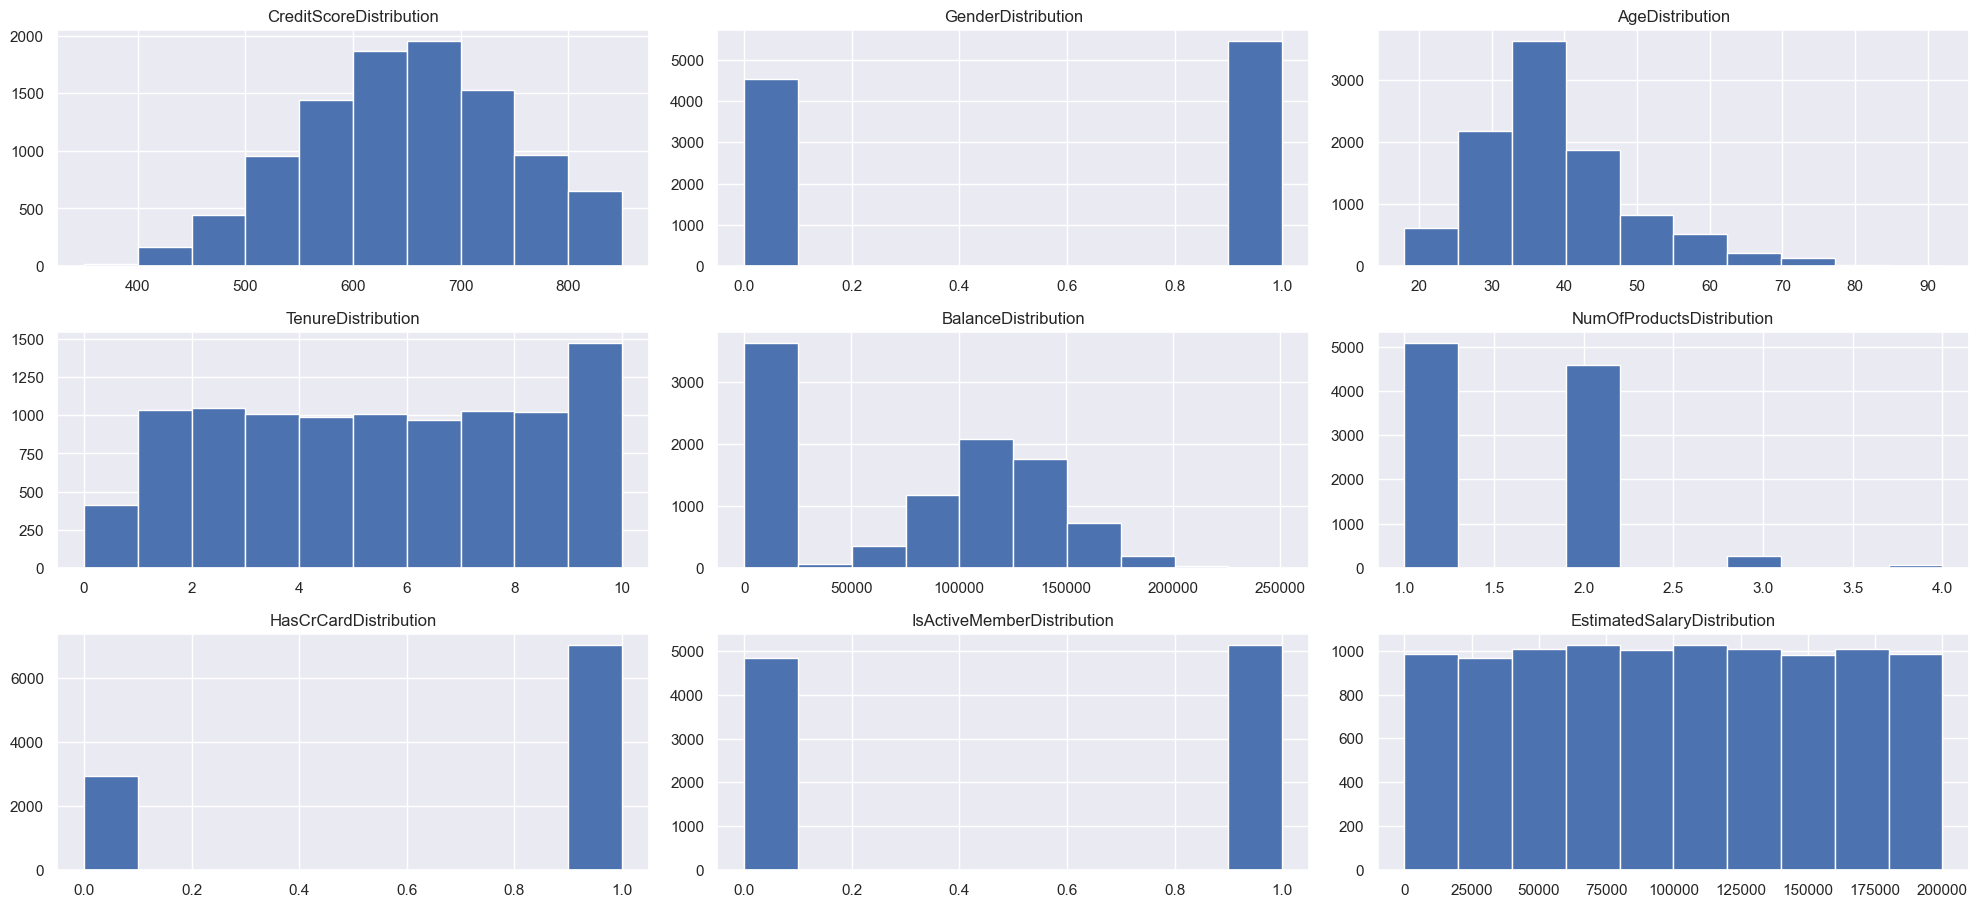

In [37]:
histograms(dataset, x1, 5,3)

# Adv EDA :Dtale--->D-Tale is a Python library that allows you to interactively explore, visualize, and edit Pandas DataFrames in your web browser — without writing code for every step.

In [ ]:
#!pip install dtale

In [38]:
import dtale
import dtale.app as dtale_app

In [39]:
dtale.show(dataset)

 * Tip: There are .env or .flaskenv files present. Do "pip install python-dotenv" to use them.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

# split the data into training and test

In [40]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_sam, y_sam, test_size=0.25, random_state=101,
                                                  stratify=y_sam )

# Building Bagging Algorithm 

In [50]:
#bagging.estimators_

[DecisionTreeClassifier(random_state=2143838369),
 DecisionTreeClassifier(random_state=242369531),
 DecisionTreeClassifier(random_state=983927689),
 DecisionTreeClassifier(random_state=226093586),
 DecisionTreeClassifier(random_state=1728635162)]

In [51]:
from sklearn.ensemble import BaggingClassifier
bagging = BaggingClassifier()
bagging.fit(x_train, y_train)

,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


# predict

In [52]:
y_pred_train_bgg = bagging.predict(x_train)
y_pred_test_bgg = bagging.predict(x_test)

# Evaluate 

In [53]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [54]:
print(confusion_matrix(y_train, y_pred_train_bgg))
print()
print(confusion_matrix(y_test, y_pred_test_bgg))

[[5945   27]
 [  11 5961]]

[[1796  195]
 [  66 1925]]


In [55]:
print(classification_report(y_train, y_pred_train_bgg))
print()
print(classification_report(y_test, y_pred_test_bgg))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5972
           1       1.00      1.00      1.00      5972

    accuracy                           1.00     11944
   macro avg       1.00      1.00      1.00     11944
weighted avg       1.00      1.00      1.00     11944


              precision    recall  f1-score   support

           0       0.96      0.90      0.93      1991
           1       0.91      0.97      0.94      1991

    accuracy                           0.93      3982
   macro avg       0.94      0.93      0.93      3982
weighted avg       0.94      0.93      0.93      3982



In [56]:
print(accuracy_score(y_train, y_pred_train_bgg))
print()
print(accuracy_score(y_test, y_pred_test_bgg))

0.9968184862692565

0.9344550477147162


# RandomForest Classifier Model

In [59]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, criterion='entropy', 
                            bootstrap=True, oob_score=False)
rf.fit(x_train, y_train)

,n_estimators,200
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
#print("OOB Score:", rf.oob_score_)

# predict

In [61]:
y_pred_train_rf = rf.predict(x_train)
y_pred_test_rf = rf.predict(x_test)

In [62]:
print(confusion_matrix(y_train, y_pred_train_rf))
print()
print(confusion_matrix(y_test, y_pred_test_rf))

[[5972    0]
 [   0 5972]]

[[1819  172]
 [  56 1935]]


In [63]:
print(classification_report(y_train, y_pred_train_rf))
print()
print(classification_report(y_test, y_pred_test_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5972
           1       1.00      1.00      1.00      5972

    accuracy                           1.00     11944
   macro avg       1.00      1.00      1.00     11944
weighted avg       1.00      1.00      1.00     11944


              precision    recall  f1-score   support

           0       0.97      0.91      0.94      1991
           1       0.92      0.97      0.94      1991

    accuracy                           0.94      3982
   macro avg       0.94      0.94      0.94      3982
weighted avg       0.94      0.94      0.94      3982



In [64]:
print(accuracy_score(y_train, y_pred_train_rf))
print()
print(accuracy_score(y_test, y_pred_test_rf))

1.0

0.9427423405323958


# Applying cross validation method in RandomForest

In [65]:
from sklearn.model_selection import cross_val_score
accuracy = cross_val_score(rf, x_train, y_train, cv=10)
accuracy.mean()


0.9408054918946196

In [68]:
print(accuracy.max())
print(accuracy.min())

0.9547738693467337
0.9221105527638191


In [69]:
print("Trainging Accuracy : ", accuracy.mean())
print()
print("Test Accuracy: ", accuracy_score(y_test, y_pred_test_rf))

Trainging Accuracy :  0.9408054918946196

Test Accuracy:  0.9427423405323958


# HyperParameter Tunning
## GridSearchCV
## RandomSearchCV

In [70]:
rf = RandomForestClassifier(random_state=42)

## n_estimators= [20,60,100,200,500]
## max_depth=[None,2,4,6,8]
## max_features=['auto',"sqrt", "log2"] 
## bootstrap=[True, False]
## max_samples=[0.5,0.75,1.0,2.0]
## min_samples_split=[2,4,8,10]
## min_samples_leaf=[1,2,4]

In [71]:
n_estimators= [20,60,100,200,500]
max_depth=[None,2,4,6,8]
min_samples_split=[2,4,8,10]
min_samples_leaf=[1,2,4]

param_grid = {'n_estimators':n_estimators,"max_depth":max_depth,
             "max_features":max_features, "bootstrap":bootstrap,
             "max_samples":max_samples, 'min_samples_split':min_samples_split,
             'min_samples_leaf':min_samples_leaf}

print(param_grid)

In [72]:
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
# 2 × 2 × 2 × 2 = 16 × 5 folds = 80 fits


In [76]:
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(estimator= rf, param_grid=param_grid, cv=5,
                     n_jobs=-1, verbose=0 )


In [77]:
rf_grid.fit(x_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 20], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 300]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [78]:
print("Best Parameters:", rf_grid.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


In [79]:
print("Best CV Score:", rf_grid.best_score_)

Best CV Score: 0.931681113815204


In [80]:
best_rf = rf_grid.best_estimator_

In [81]:
y_pred = best_rf.predict(x_test)

In [83]:
y_pred_1 = best_rf.predict(x_train)

In [85]:
print("Train Accuracy:", accuracy_score(y_train, y_pred_1))

Train Accuracy: 1.0


In [82]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.9417378201908588


# RandomSearchCV



In [86]:
from sklearn.model_selection import RandomizedSearchCV

In [87]:
# Parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [88]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [89]:
# Train the model
random_search.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [90]:
# Best Parameters
random_search.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_depth': 20,
 'criterion': 'entropy'}

In [91]:
random_search.best_score_

0.9233087791405751

In [92]:
best_rf_1 = random_search.best_estimator_
best_rf_1

,n_estimators,100
,criterion,'entropy'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
from sklearn.metrics import accuracy_score

y_pred = best_rf_1.predict(x_test)

accuracy_score(y_test, y_pred)

0.9354595680562532

| Method             | Idea                      | Speed |
| ------------------ | ------------------------- | ----- |
| GridSearchCV       | tries all combinations    | slow  |
| RandomizedSearchCV | tries random combinations | fast  |


| Verbose | Output Level                |
| ------- | --------------------------- |
| 0       | No output                   |
| 1       | Basic progress              |
| 2       | More detailed progress      |
| 3       | Full detailed training info |


# n_jobs=-1 , Uses all CPU cores for parallel processing.

# Training becomes much faster.